# 35 - Six-channel virtual IMU: code and saved results

Executed healthy GAITEX pilot, 9 September 2026. This notebook preserves readable
outputs without rerunning generation. Code below defines the original pilot;
executed reporting cells reload its existing artifacts. It does not imply that
the original generation was executed inside this notebook.

**Result:** 18 healthy participants, 55 windows of 500 x 6. One missing-source
parent. Pelvis marker frame, not L5; no stroke transformation or classifier gain.


In [1]:
from pathlib import Path
import sys, json, hashlib
import numpy as np
import pandas as pd
from IPython.display import display
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'AGENTS.md').exists())
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
ARTIFACT = ROOT/'data/processed/stroke_synthesis_v1/rigid_imu_pilot'
print('Mode: read-only replay of saved results; generation and training disabled.')

Mode: read-only replay of saved results; generation and training disabled.


## Experiment code

The full experiment orchestration is retained here for inspection. Defining
`main()` does not execute it. It refuses to overwrite the original output folder.
The reusable physics implementation remains in `src/data/virtual_imu.py`.


In [2]:
"""Bounded healthy GAITEX rigid-plate pilot; no stroke labels or classifier use."""
import hashlib
import json
from pathlib import Path

import numpy as np
import pandas as pd

from src.data.virtual_imu import virtual_imu

# ROOT is set by the notebook setup cell
DATA = ROOT / 'data/archive/raw/gaitex_2026/data'
OUT = ROOT / 'data/processed/stroke_synthesis_v1/rigid_imu_pilot'


def main():
    # Commit roles before inspecting generated signals. These are development
    # roles only: GAITEX has already been inspected by earlier experiments.
    parents = sorted(p.name for p in DATA.iterdir() if p.is_dir())
    ranked = sorted(parents, key=lambda p: hashlib.sha256(('synthesis-v1:'+p).encode()).hexdigest())
    held = set(ranked[:max(1, len(parents)//4)])
    roles = {p: 'development_holdout' if p in held else 'development_build' for p in parents}
    OUT.mkdir(parents=True, exist_ok=False)
    (OUT/'parent_roles.json').write_text(json.dumps(dict(
        roles=roles, final_test=False, prior_exposure=True,
        scope='GAITEX healthy engineering pilot only; not a clinical training split',
        rule='SHA256(synthesis-v1:parent), first floor(n/4) parents held out'), indent=2))
    signals, rows = [], []
    for parent in parents:
        folder = DATA/parent/'ng'
        stem = parent+'_ng'
        trc = folder/'ik_imus'/f'marker_data_osim_format_{stem}.trc'
        meta = folder/f'metadata_{stem}.json'
        segments = folder/f'timestamps_{stem}.csv'
        if not all(p.exists() for p in [trc, meta, segments]):
            rows.append(dict(parent=parent, status='missing_source', role=roles[parent]))
            continue
        names = json.loads(meta.read_text())['inverse_kinematics']['pelvis']['marker_names'][:3]
        with trc.open() as f:
            header = [next(f) for _ in range(5)]
        if 'mm' not in header[2].split():
            raise ValueError(f'{parent}: TRC units not verified as mm')
        markers = [v for v in header[3].strip().split('\t') if v not in ('Frame#', 'Time', '')]
        columns = ['Frame', 'Time']+[f'{m}_{a}' for m in markers for a in 'xyz']
        selected = ['Time']+[f'{m}_{a}' for m in names for a in 'xyz']
        frame = pd.read_csv(trc, sep=r'\s+', skiprows=5, names=columns, usecols=selected)
        time = frame.Time.to_numpy(float)
        points = frame[selected[1:]].to_numpy(float).reshape(-1, 3, 3)/1000
        valid = np.isfinite(points).all(axis=(1, 2)) & ~np.isclose(points, 0).all(axis=2).any(axis=1)
        x = points[:, 0]-points[:, 1]
        z = np.cross(x, points[:, 2]-points[:, 1])
        valid &= (np.linalg.norm(x, axis=1)>1e-6) & (np.linalg.norm(z, axis=1)>1e-8)
        digest = hashlib.sha256(trc.read_bytes()).hexdigest()
        for label, start, stop, speed in pd.read_csv(segments).itertuples(index=False, name=None):
            mask = valid & (time>=start) & (time<=stop)
            edges = np.flatnonzero(np.diff(np.r_[False, mask, False])).reshape(-1, 2)
            candidates = [(a, b) for a, b in edges if b-a>=520]
            row = dict(parent=parent, segment=label, role=roles[parent], speed_km_h=speed,
                       source=str(trc.relative_to(ROOT)), source_sha256=digest,
                       annotated_frames=int(((time>=start)&(time<=stop)).sum()),
                       valid_frames=int(mask.sum()))
            if not candidates:
                rows.append(row | dict(status='no_contiguous_520_frame_run'))
                continue
            a, _ = candidates[0]; b = a+520
            xx = x[a:b]/np.linalg.norm(x[a:b], axis=1)[:, None]
            zz = z[a:b]/np.linalg.norm(z[a:b], axis=1)[:, None]
            yy = np.cross(zz, xx)
            rotation = np.stack([xx, yy, zz], axis=2)
            try:
                tt, imu = virtual_imu(time[a:b], points[a:b].mean(axis=1), rotation,
                    offset_body_m=[0, 0, 0], sensor_to_body=np.eye(3),
                    gravity_world_m_s2=[0, -9.80665, 0])
            except ValueError as error:
                rows.append(row | dict(status='invalid_run', reason=str(error)))
                continue
            index = len(signals); signals.append(imu.astype(np.float32))
            rows.append(row | dict(status='generated', output_index=index, start_s=float(tt[0]),
                samples=len(tt), median_specific_force_m_s2=float(np.median(np.linalg.norm(imu[:, :3], axis=1))),
                rms_gyro_rad_s=float(np.sqrt(np.mean(imu[:, 3:]**2)))))
        print(parent, 'complete', flush=True)
    if signals: np.save(OUT/'pelvis_plate_6ch.npy', np.stack(signals))
    pd.DataFrame(rows).to_csv(OUT/'coverage.csv', index=False)
    generated = [r for r in rows if r['status']=='generated']
    summary = dict(parents_available=len(parents), parents_generated=len({r['parent'] for r in generated}),
        windows=len(signals), shape=list(np.stack(signals).shape) if signals else [],
        skipped_rows=[r for r in rows if r['status']!='generated'],
        channel_order=['ax', 'ay', 'az', 'gx', 'gy', 'gz'], units=['m/s2']*3+['rad/s']*3,
        placement='pelvis_marker_plate_centroid_not_l5',
        orientation='orthonormal marker frame, not hardware IMU axes',
        smoothing_samples=21, edge_trim_each_side=10,
        sampling='first valid 520-frame run per annotated normal segment; 500 output samples',
        purpose='healthy rigid-attachment engineering feasibility, not stroke synthesis or measurement validation',
        eligible_for_classifier_training=False, clinical_parameters_applied=False,
        new_raw_acquisition=False, revalexo_used=False)
    (OUT/'summary.json').write_text(json.dumps(summary, indent=2))
    print(json.dumps(summary, indent=2))


# Generation is intentionally not called during a read-only replay.


## Saved cohort result and exclusions

In [3]:
summary = json.loads((ARTIFACT/'summary.json').read_text())
coverage = pd.read_csv(ARTIFACT/'coverage.csv')
roles = json.loads((ARTIFACT/'parent_roles.json').read_text())
display(pd.DataFrame([{'participants':summary['parents_generated'], 'inventoried':summary['parents_available'], 'windows':summary['windows'], 'samples':summary['shape'][1], 'channels':summary['shape'][2]}]))
display(coverage.groupby(['role','status'], dropna=False).agg(parents=('parent','nunique'), segments=('parent','size')).reset_index())
display(coverage.loc[coverage.status.ne('generated'), ['parent','role','status']])
print('Placement:', summary['placement'])
print('Classifier-training eligible:', summary['eligible_for_classifier_training'])

,participants,inventoried,windows,samples,channels
0,18,19,55,500,6


,role,status,parents,segments
0,development_build,generated,14,43
1,development_build,missing_source,1,1
2,development_holdout,generated,4,12


,parent,role,status
21,hans,development_build,missing_source


Placement: pelvis_marker_plate_centroid_not_l5
Classifier-training eligible: False


## Read-only artifact checks and provenance

In [4]:
windows = np.load(ARTIFACT/'pelvis_plate_6ch.npy')
generated = coverage.loc[coverage.status.eq('generated')]
assert list(windows.shape) == summary['shape']
assert np.isfinite(windows).all()
assert generated.output_index.tolist() == list(range(len(windows)))
assert generated.groupby('parent').role.nunique().eq(1).all()
assert all(roles['roles'][r.parent] == r.role for r in generated.itertuples())
print('PASS: shape, finite channels, output indices and parent roles.')
display(pd.DataFrame([{'file':p.name,'sha256':hashlib.sha256(p.read_bytes()).hexdigest()} for p in sorted(ARTIFACT.iterdir()) if p.is_file()]))

PASS: shape, finite channels, output indices and parent roles.


,file,sha256
0,coverage.csv,dcc77fbd85c04fc76057cee19060733d60f99511808c4e...
1,parent_roles.json,638395a1f9e8502fac9c89199b7377ef2cf126986f308d...
2,pelvis_plate_6ch.npy,146ba116c38c8609c1d87034ee83f3594390b85636937f...
3,summary.json,5261716d9efd3fbb800a98103e0824e32570eb408c87c3...
4,verification.json,70c4f4aa12417ee38c226db399ef7a435ee2c22f4f5b0b...


## Six-channel example

First saved window, plotted as an illustration, not a selected best case or a
cohort accuracy measure. Acceleration is specific force in m/s2; gyro is rad/s.


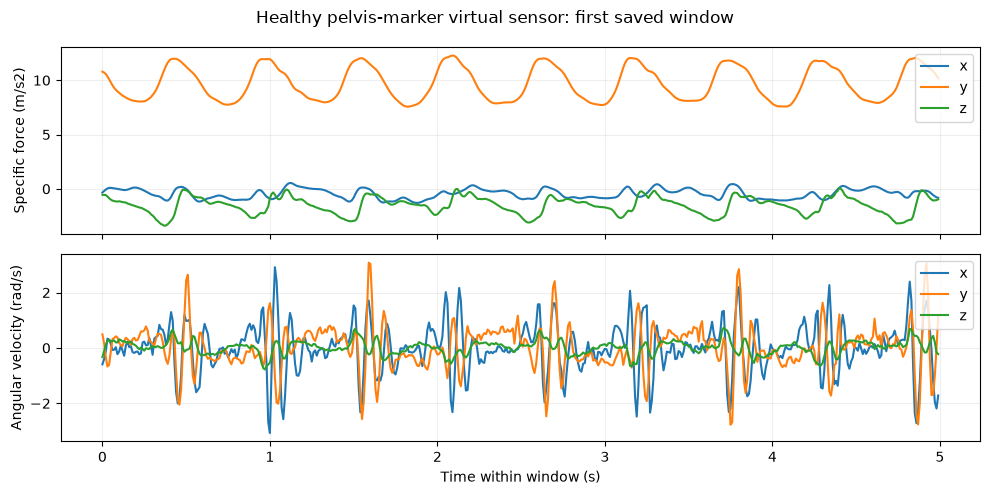

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
time = np.arange(windows.shape[1])/100
for j, name in enumerate(['x','y','z']):
    axes[0].plot(time, windows[0,:,j], label=name)
    axes[1].plot(time, windows[0,:,j+3], label=name)
axes[0].set_ylabel('Specific force (m/s2)')
axes[1].set_ylabel('Angular velocity (rad/s)')
axes[1].set_xlabel('Time within window (s)')
for ax in axes: ax.legend(loc='upper right'); ax.grid(alpha=.2)
fig.suptitle('Healthy pelvis-marker virtual sensor: first saved window')
fig.tight_layout()
display(fig)
plt.close(fig)

## Interpretation

This read-only replay verifies stored outputs; it is not a new acquisition,
training run or clinical evaluation. It does not rerun the six previously passed
physics tests. Source hashes above identify the saved artifacts used here.
Healthy motion, engineering development roles and marker-frame placement cannot
be relabeled as validated stroke generation, independent clinical testing or L5.
